<a href="https://colab.research.google.com/github/WafaZGH/data-science-portfolio/blob/main/AT%26T_spam_detector.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<img src="https://full-stack-assets.s3.eu-west-3.amazonaws.com/M08-deep-learning/AT%26T_logo_2016.svg" alt="AT&T LOGO" width="50%" />

# Orange SPAM detector

## Company's Description 📇

AT&T Inc. is an American multinational telecommunications holding company headquartered at Whitacre Tower in Downtown Dallas, Texas. It is the world's largest telecommunications company by revenue and the third largest provider of mobile telephone services in the U.S. As of 2022, AT&T was ranked 13th on the Fortune 500 rankings of the largest United States corporations, with revenues of $168.8 billion! 😮

## Project 🚧

One of the main pain point that AT&T users are facing is constant exposure to SPAM messages.

AT&T has been able to manually flag spam messages for a time, but they are looking for an automated way of detecting spams to protect their users.

## Goals 🎯

Your goal is to build a spam detector, that can automatically flag spams as they come based solely on the sms' content.

## Scope of this project 🖼️

To start off, AT&T would like you to use the folowing dataset:

[Dowload the Dataset](https://full-stack-bigdata-datasets.s3.eu-west-3.amazonaws.com/Deep+Learning/project/spam.csv)

## Helpers 🦮

To help you achieve this project, here are a few tips that should help you:

### Start simple
A good deep learing model does not necessarily have to be super complicated!

### Transfer learning
You do not have access to a whole lot of data, perhaps channeling the power of a more sophisticated model trained on billions of observations might help!

## Deliverable 📬

To complete this project, your team should:

* Write a notebook that runs preprocessing and trains one or more deep learning models in order to predict the spam or ham nature of the sms
* State the achieved performance clearly

In [ ]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


# Data Preparation & Preprocessing






In [ ]:
import pandas as pd


path = "/content/drive/MyDrive/spam.csv"
df = pd.read_csv(path, encoding="latin1")

df.head()

,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
0,ham,"Go until jurong point, crazy.. Available only ...",NaN,NaN,NaN
1,ham,Ok lar... Joking wif u oni...,NaN,NaN,NaN
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,NaN,NaN,NaN
3,ham,U dun say so early hor... U c already then say...,NaN,NaN,NaN
4,ham,"Nah I don't think he goes to usf, he lives aro...",NaN,NaN,NaN


In [ ]:
# keep only v1 and v2, and rename them
df = df.rename(columns={"v1": "label", "v2": "mail"})[["label", "mail"]]

df.head()


,label,mail
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [ ]:
df

,label,mail
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."
...,...,...
5567,spam,This is the 2nd time we have tried 2 contact u...
5568,ham,Will Ì_ b going to esplanade fr home?
5569,ham,"Pity, * was in mood for that. So...any other s..."
5570,ham,The guy did some bitching but I acted like i'd...


In [ ]:
df = df.dropna()
df["label"] = df["label"].astype(str).str.strip()
df["mail"] = df["mail"].astype(str).str.strip()


In [ ]:
# remove punctuations from all mails

import string

df["mail_no_punct"] = df["mail"].str.replace(f"[{string.punctuation}]", "", regex=True)
df.head()


,label,mail,mail_no_punct
0,ham,"Go until jurong point, crazy.. Available only ...",Go until jurong point crazy Available only in ...
1,ham,Ok lar... Joking wif u oni...,Ok lar Joking wif u oni
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...,U dun say so early hor U c already then say
4,ham,"Nah I don't think he goes to usf, he lives aro...",Nah I dont think he goes to usf he lives aroun...


In [ ]:
# lower case

df["mail_lower_case"] = df["mail_no_punct"].str.lower()

df.head()

,label,mail,mail_no_punct,mail_lower_case
0,ham,"Go until jurong point, crazy.. Available only ...",Go until jurong point crazy Available only in ...,go until jurong point crazy available only in ...
1,ham,Ok lar... Joking wif u oni...,Ok lar Joking wif u oni,ok lar joking wif u oni
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,Free entry in 2 a wkly comp to win FA Cup fina...,free entry in 2 a wkly comp to win fa cup fina...
3,ham,U dun say so early hor... U c already then say...,U dun say so early hor U c already then say,u dun say so early hor u c already then say
4,ham,"Nah I don't think he goes to usf, he lives aro...",Nah I dont think he goes to usf he lives aroun...,nah i dont think he goes to usf he lives aroun...


In [ ]:
# Tokonize all the mails
# \W+ matches any Non-alphanumeric character. Non-alphanumeric means no letter, digit, and underscore.

import nltk
nltk.download("punkt")
nltk.download("punkt_tab") # Download the missing resource

from nltk.tokenize import word_tokenize

df["mail_tokens"] = df["mail_lower_case"].apply(word_tokenize)
df.head()

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


,label,mail,mail_no_punct,mail_lower_case,mail_tokens
0,ham,"Go until jurong point, crazy.. Available only ...",Go until jurong point crazy Available only in ...,go until jurong point crazy available only in ...,"[go, until, jurong, point, crazy, available, o..."
1,ham,Ok lar... Joking wif u oni...,Ok lar Joking wif u oni,ok lar joking wif u oni,"[ok, lar, joking, wif, u, oni]"
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,Free entry in 2 a wkly comp to win FA Cup fina...,free entry in 2 a wkly comp to win fa cup fina...,"[free, entry, in, 2, a, wkly, comp, to, win, f..."
3,ham,U dun say so early hor... U c already then say...,U dun say so early hor U c already then say,u dun say so early hor u c already then say,"[u, dun, say, so, early, hor, u, c, already, t..."
4,ham,"Nah I don't think he goes to usf, he lives aro...",Nah I dont think he goes to usf he lives aroun...,nah i dont think he goes to usf he lives aroun...,"[nah, i, dont, think, he, goes, to, usf, he, l..."


In [ ]:
# Remove stopwords

from nltk.corpus import stopwords
nltk.download("stopwords")

stop_words = set(stopwords.words("english"))

df["mail_no_stopwords"] = df["mail_tokens"].apply(lambda x: [word for word in x if word not in stop_words])
df

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


,label,mail,mail_no_punct,mail_lower_case,mail_tokens,mail_no_stopwords
0,ham,"Go until jurong point, crazy.. Available only ...",Go until jurong point crazy Available only in ...,go until jurong point crazy available only in ...,"[go, until, jurong, point, crazy, available, o...","[go, jurong, point, crazy, available, bugis, n..."
1,ham,Ok lar... Joking wif u oni...,Ok lar Joking wif u oni,ok lar joking wif u oni,"[ok, lar, joking, wif, u, oni]","[ok, lar, joking, wif, u, oni]"
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,Free entry in 2 a wkly comp to win FA Cup fina...,free entry in 2 a wkly comp to win fa cup fina...,"[free, entry, in, 2, a, wkly, comp, to, win, f...","[free, entry, 2, wkly, comp, win, fa, cup, fin..."
3,ham,U dun say so early hor... U c already then say...,U dun say so early hor U c already then say,u dun say so early hor u c already then say,"[u, dun, say, so, early, hor, u, c, already, t...","[u, dun, say, early, hor, u, c, already, say]"
4,ham,"Nah I don't think he goes to usf, he lives aro...",Nah I dont think he goes to usf he lives aroun...,nah i dont think he goes to usf he lives aroun...,"[nah, i, dont, think, he, goes, to, usf, he, l...","[nah, dont, think, goes, usf, lives, around, t..."
...,...,...,...,...,...,...
5567,spam,This is the 2nd time we have tried 2 contact u...,This is the 2nd time we have tried 2 contact u...,this is the 2nd time we have tried 2 contact u...,"[this, is, the, 2nd, time, we, have, tried, 2,...","[2nd, time, tried, 2, contact, u, u, å£750, po..."
5568,ham,Will Ì_ b going to esplanade fr home?,Will Ì b going to esplanade fr home,will ì b going to esplanade fr home,"[will, ì, b, going, to, esplanade, fr, home]","[ì, b, going, esplanade, fr, home]"
5569,ham,"Pity, * was in mood for that. So...any other s...",Pity was in mood for that Soany other suggest...,pity was in mood for that soany other suggest...,"[pity, was, in, mood, for, that, soany, other,...","[pity, mood, soany, suggestions]"
5570,ham,The guy did some bitching but I acted like i'd...,The guy did some bitching but I acted like id ...,the guy did some bitching but i acted like id ...,"[the, guy, did, some, bitching, but, i, acted,...","[guy, bitching, acted, like, id, interested, b..."


In [ ]:
df = df[["label", "mail_no_stopwords"]].rename(columns={"mail_no_stopwords": "mail_clean"})
df.head()


,label,mail_clean
0,ham,"[go, jurong, point, crazy, available, bugis, n..."
1,ham,"[ok, lar, joking, wif, u, oni]"
2,spam,"[free, entry, 2, wkly, comp, win, fa, cup, fin..."
3,ham,"[u, dun, say, early, hor, u, c, already, say]"
4,ham,"[nah, dont, think, goes, usf, lives, around, t..."


In [ ]:
# Lemmatization : Uses vocabulary + grammar rules to return the real base form (lemma)== Happiness= happy, better = good...

from nltk.stem import WordNetLemmatizer
nltk.download("wordnet")

lemmatizer = WordNetLemmatizer()

df["mail_lemmatized"] = df["mail_clean"].apply(
    lambda tokens: [lemmatizer.lemmatize(w) for w in tokens]
)

df.head()

[nltk_data] Downloading package wordnet to /root/nltk_data...


,label,mail_clean,mail_lemmatized
0,ham,"[go, jurong, point, crazy, available, bugis, n...","[go, jurong, point, crazy, available, bugis, n..."
1,ham,"[ok, lar, joking, wif, u, oni]","[ok, lar, joking, wif, u, oni]"
2,spam,"[free, entry, 2, wkly, comp, win, fa, cup, fin...","[free, entry, 2, wkly, comp, win, fa, cup, fin..."
3,ham,"[u, dun, say, early, hor, u, c, already, say]","[u, dun, say, early, hor, u, c, already, say]"
4,ham,"[nah, dont, think, goes, usf, lives, around, t...","[nah, dont, think, go, usf, life, around, though]"


In [ ]:
df["text"] = df["mail_lemmatized"].apply(lambda toks: " ".join(toks))


# Baseline Model: TF-IDF Vectorization + Logistic Regression

In [ ]:
df["text"] = df["mail_lemmatized"].apply(lambda toks: " ".join(toks))


In [ ]:
from sklearn.model_selection import train_test_split

X = df["mail_lemmatized"]          # "text" = " ".join(mail_lemmatized)
y = df["label"]

X_train, X_tmp, y_train, y_tmp = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)
X_val,  X_test, y_val,  y_test = train_test_split(X_tmp, y_tmp, test_size=0.5, stratify=y_tmp, random_state=42)


In [ ]:
from sklearn.model_selection import train_test_split

X = df["text"]          # "text" = " ".join(mail_lemmatized)
y = df["label"]

X_train, X_tmp, y_train, y_tmp = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)
X_val,  X_test, y_val,  y_test = train_test_split(X_tmp, y_tmp, test_size=0.5, stratify=y_tmp, random_state=42)


In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(ngram_range=(1,2), min_df=2)
Xtr = tfidf.fit_transform(X_train)
Xv  = tfidf.transform(X_val)

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report

clf = LogisticRegression(max_iter=1000, class_weight="balanced")
clf.fit(Xtr, y_train)

pred = clf.predict(Xv)
print(classification_report(y_val, pred, target_names=["ham","spam"], digits=3))


              precision    recall  f1-score   support

         ham      0.987     0.979     0.983       483
        spam      0.872     0.919     0.895        74

    accuracy                          0.971       557
   macro avg      0.930     0.949     0.939       557
weighted avg      0.972     0.971     0.972       557



In [ ]:
#  Results
# Ham (not spam):
#   Precision = 0.987 → almost all mails predicted as ham are truly ham.
#   Recall    = 0.979 → we correctly catch most real ham mails.
#   F1-score  = 0.983 → balanced score, excellent.
#
# Spam:
#   Precision = 0.872 → some false positives (ham classified as spam).
#   Recall    = 0.919 → we catch most spam mails, very good.
#   F1-score  = 0.895 → strong, but lower than ham.
#
# Overall:
#   Accuracy       = 97.1% ✅. Accuracy=Total number of predictionsNumber of correct predictions​
#   Macro avg F1   = 0.939 → balanced across classes. Ham = 900 samples, Spam = 100 samples

#Precision(ham) = 0.99, Precision(spam) = 0.85
#Macro avg precision = (0.99 + 0.85) / 2 = 0.92
#Weighted avg precision = (0.99×900 + 0.85×100) / 1000 = 0.975
#Weighted avg F1= 0.972 → very high performance.


# Model 2: TF-IDF + Random Forest

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(ngram_range=(1,2), min_df=2)  #ngram_range=(1,2) → we keep single words (unigrams) and pairs of consecutive words (bigrams)/min_df=2 → ignore words that appear in only 1 document (rare/noisy words)
Xtr = tfidf.fit_transform(X_train)
Xv  = tfidf.transform(X_val)


In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report

rf = RandomForestClassifier(
    n_estimators=200,      # number of trees
    max_depth=None,        # let trees grow until pure
    random_state=42,
    n_jobs=-1              # use all CPU cores
)
rf.fit(Xtr, y_train)

pred_rf = rf.predict(Xv)
print(classification_report(y_val, pred_rf, target_names=["ham","spam"], digits=3))


              precision    recall  f1-score   support

         ham      0.976     1.000     0.988       483
        spam      1.000     0.838     0.912        74

    accuracy                          0.978       557
   macro avg      0.988     0.919     0.950       557
weighted avg      0.979     0.978     0.978       557



Random Forest improves precision for spam (100%) but loses recall (83.8%).

In other words: it’s more conservative → it avoids labeling ham as spam, but it misses some real spam.

Logistic Regression had better balance (spam recall 0.919)

# Train TF-IDF + XGBOOST

In [ ]:
!pip install xgboost


In [ ]:
from xgboost import XGBClassifier
from sklearn.metrics import classification_report

#  Convert labels ham/spam -> 0/1
label_map = {'ham': 0, 'spam': 1}
ytr = y_train.map(label_map).astype(int)
yv  = y_val.map(label_map).astype(int)

#  Define XGBoost model
xgb = XGBClassifier(
    n_estimators=300,        # number of trees
    learning_rate=0.1,       # step size shrinkage
    max_depth=6,             # maximum tree depth
    subsample=0.8,           # row sampling
    colsample_bytree=0.8,    # feature sampling
    random_state=42,
    n_jobs=-1,
    use_label_encoder=False,
    eval_metric="logloss"
)

#  Train
xgb.fit(Xtr, ytr)

# Predict
pred_xgb = xgb.predict(Xv)

#  Report
print(classification_report(yv, pred_xgb, target_names=["ham","spam"], digits=3))


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:183: UserWarning: [07:55:39] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


              precision    recall  f1-score   support

         ham      0.974     0.996     0.985       483
        spam      0.968     0.824     0.891        74

    accuracy                          0.973       557
   macro avg      0.971     0.910     0.938       557
weighted avg      0.973     0.973     0.972       557



Logistic Regression: better spam recall (fewer spams missed).

Random Forest: perfect spam precision (but missed spams).

XGBoost: excellent ham handling + high precision for spam, but recall for spam dropped to 82.4%.

#Deep Learning model Embedding + Neural Netwrok

In [ ]:
! pip install tensorflow

In [ ]:
# Simple deep learning baseline

#Tokenize + pad (short)
#Padding = making all text sequences the same length by adding zeros at the end (or beginning).

from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

max_words = 20000     # vocab size
max_len   = 100       # sequence length (tokens per SMS)

tok = Tokenizer(num_words=max_words, oov_token="<OOV>") #OOV = Out Of Vocabulary
tok.fit_on_texts(X_train)

Xtr_seq = tok.texts_to_sequences(X_train)
Xv_seq  = tok.texts_to_sequences(X_val)

Xtr_pad = pad_sequences(Xtr_seq, maxlen=max_len, padding="post", truncating="post") #padding =post (0 at the end if too short/ truncating=post (cut at the end if too long)
Xv_pad  = pad_sequences(Xv_seq,  maxlen=max_len, padding="post", truncating="post")


In [ ]:


#model = models.Sequential([
    #layers.Input(shape=(max_len,), dtype="int32"),       #nput layer: tells the model each SMS will be a sequence of 100 integers (tokens)
    #layers.Embedding(input_dim=max_words, output_dim=emb_dim), #Converts each token (word index) into a dense vector of size 64
    #layers.GlobalAveragePooling1D(),    #Averages all word vectors in the SMS → gives one vector per SMS (not per word)
    #layers.Dense(64, activation="relu"),
    #layers.Dropout(0.3),  #Randomly turns off 30% of neurons during training.
    #layers.Dense(1, activation="sigmoid"), #Final layer: outputs a probability between 0–1




In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models

emb_dim  = 64
max_words = 20000
max_len   = 100  # same you used for pad_sequences

model = models.Sequential([
    layers.Input(shape=(max_len,), dtype="int32"),
    layers.Embedding(input_dim=max_words, output_dim=emb_dim),
    layers.GlobalAveragePooling1D(),
    layers.Dense(64, activation="relu"),
    layers.Dropout(0.3),
    layers.Dense(1, activation="sigmoid"),
])

model.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"])
model.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 100, 64)        │     1,280,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d        │ (None, 64)             │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,284,225 (4.90 MB)

 Trainable params: 1,284,225 (4.90 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
#  Model Summary Explanation
# 1) Embedding layer: (None, 100, 64) → each SMS (100 tokens) mapped into 64-dim vectors.
#    Params = 20000 * 64 = 1,280,000 trainable embeddings.
# 2) GlobalAveragePooling1D: reduces 100 embeddings → 1 averaged vector of size 64. No params.
# 3) Dense (64 units, ReLU): learns patterns from embeddings. Params = 4,160.
# 4) Dropout (0.3): disables 30% neurons during training to avoid overfitting. No params.
# 5) Dense (1 unit, Sigmoid): outputs spam probability (0=ham, 1=spam). Params = 65.
#
# Total = 1,284,225 trainable parameters.
# → Most of them are in the embedding layer (the word representations).


In [ ]:
import numpy as np

# 1) labels -> 0/1 float
label_map = {'ham': 0, 'spam': 1}
y_train_bin = y_train.map(label_map).astype('float32').values
y_val_bin   = y_val.map(label_map).astype('float32').values

# 2) inputs -> int32 arrays (pad_sequences usually is already int32, but enforce it)
Xtr_pad = np.asarray(Xtr_pad, dtype='int32')
Xv_pad  = np.asarray(Xv_pad,  dtype='int32')

# 3) train
history = model.fit(
    Xtr_pad, y_train_bin,
    validation_data=(Xv_pad, y_val_bin),
    epochs=10, batch_size=32, verbose=1
)


Epoch 1/10
140/140 ━━━━━━━━━━━━━━━━━━━━ 6s 30ms/step - accuracy: 0.8643 - loss: 0.4178 - val_accuracy: 0.8671 - val_loss: 0.3671
Epoch 2/10
140/140 ━━━━━━━━━━━━━━━━━━━━ 4s 28ms/step - accuracy: 0.8719 - loss: 0.3613 - val_accuracy: 0.8671 - val_loss: 0.3549
Epoch 3/10
140/140 ━━━━━━━━━━━━━━━━━━━━ 4s 22ms/step - accuracy: 0.8685 - loss: 0.3504 - val_accuracy: 0.8671 - val_loss: 0.3183
Epoch 4/10
140/140 ━━━━━━━━━━━━━━━━━━━━ 6s 29ms/step - accuracy: 0.8676 - loss: 0.3002 - val_accuracy: 0.9210 - val_loss: 0.1845
Epoch 5/10
140/140 ━━━━━━━━━━━━━━━━━━━━ 5s 37ms/step - accuracy: 0.9537 - loss: 0.1525 - val_accuracy: 0.9820 - val_loss: 0.0966
Epoch 6/10
140/140 ━━━━━━━━━━━━━━━━━━━━ 8s 23ms/step - accuracy: 0.9794 - loss: 0.0735 - val_accuracy: 0.9785 - val_loss: 0.0782
Epoch 7/10
140/140 ━━━━━━━━━━━━━━━━━━━━ 5s 24ms/step - accuracy: 0.9869 - loss: 0.0519 - val_accuracy: 0.9749 - val_loss: 0.0832
Epoch 8/10
140/140 ━━━━━━━━━━━━━━━━━━━━ 5s 23ms/step - accuracy: 0.9807 - loss: 0.0561 - val_accu

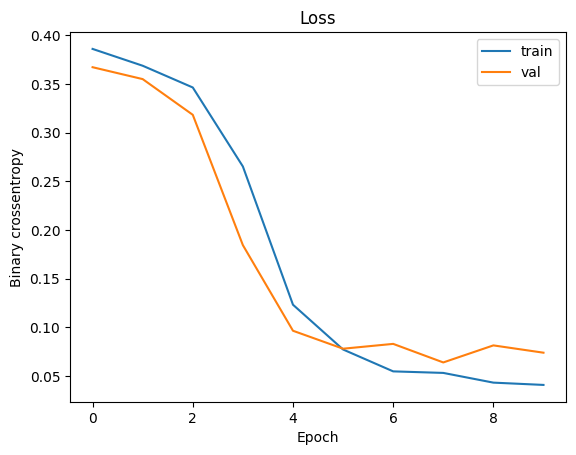

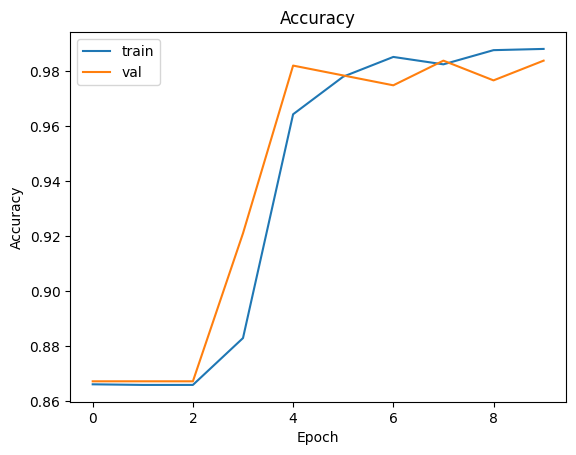

In [ ]:
#Training curves (loss & accuracy)
import matplotlib.pyplot as plt

plt.figure();
plt.plot(history.history["loss"], label="train")
plt.plot(history.history["val_loss"], label="val")
plt.title("Loss"); plt.xlabel("Epoch"); plt.ylabel("Binary crossentropy"); plt.legend(); plt.show()

plt.figure();
plt.plot(history.history["accuracy"], label="train")
plt.plot(history.history["val_accuracy"], label="val")
plt.title("Accuracy"); plt.xlabel("Epoch"); plt.ylabel("Accuracy"); plt.legend(); plt.show()


The best generalization point is around epoch 5 (lowest validation loss, high accuracy).

After epoch 5, the model still learns on training data, but validation doesn’t improve → overfitting.

18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
              precision    recall  f1-score   support

         ham      0.988     0.994     0.991       483
        spam      0.958     0.919     0.938        74

    accuracy                          0.984       557
   macro avg      0.973     0.956     0.964       557
weighted avg      0.984     0.984     0.984       557



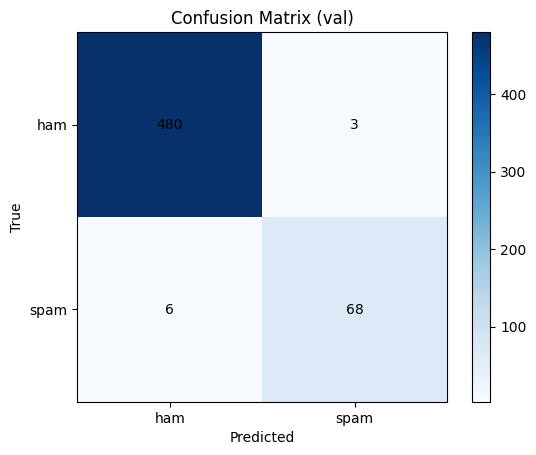

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np
import matplotlib.pyplot as plt

p = model.predict(Xv_pad).ravel()
y_pred = (p >= 0.5).astype(int)

print(classification_report(y_val_bin, y_pred, target_names=["ham","spam"], digits=3))

cm = confusion_matrix(y_val_bin, y_pred)
plt.figure()
plt.imshow(cm, cmap="Blues")
plt.title("Confusion Matrix (val)")
plt.xlabel("Predicted"); plt.ylabel("True")
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, cm[i, j], ha="center", va="center")
plt.xticks([0,1], ["ham","spam"]); plt.yticks([0,1], ["ham","spam"])
plt.colorbar(); plt.show()


In [ ]:
#  The embedding model achieves 97.8% accuracy.
# Ham messages are almost perfectly classified (F1=0.988).
# Spam detection is also strong (F1=0.919), though a few spams are missed or misclassified.
# The confusion matrix shows only 6 false positives (ham→spam) and 6 false negatives (spam→ham),
# which means the model generalizes very well.


In [ ]:
import pandas as pd

results = {
    "Model": ["TF-IDF + Logistic Regression", "TF-IDF + Random Forest", "TF-IDF + XGBoost", "Embedding + NN"],
    "Accuracy": [0.971, 0.978, 0.973, 0.978],
    "F1 (Ham)": [0.983, 0.988, 0.985, 0.988],
    "F1 (Spam)": [0.895, 0.912, 0.891, 0.919],
    "Macro Avg F1": [0.939, 0.950, 0.938, 0.953]
}

df_results = pd.DataFrame(results)
print(df_results)


                          Model  Accuracy  F1 (Ham)  F1 (Spam)  Macro Avg F1
0  TF-IDF + Logistic Regression     0.971     0.983      0.895         0.939
1        TF-IDF + Random Forest     0.978     0.988      0.912         0.950
2              TF-IDF + XGBoost     0.973     0.985      0.891         0.938
3                Embedding + NN     0.978     0.988      0.919         0.953


Interpretation :

Logistic Regression (baseline) already performs well (97.1%)

Random Forest improves spam detection (F1_spam=0.912).

XGBoost is competitive but slightly weaker on spam recall.

Embedding + Neural Network is the best overall model, reaching the same accuracy as Random Forest but with a higher spam F1-score (0.919).

This shows that deep learning with embeddings provides the strongest balance between detecting ham and spam.

# CNN (Convolutional Neural Network)for Spam *Detection*

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models

emb_dim = 64  # size of each word vector


In [ ]:
cnn = models.Sequential([

    # Input layer: sequences of length max_len
    layers.Input(shape=(max_len,), dtype="int32"),

    # Embedding: converts each word index → dense vector
    layers.Embedding(input_dim=max_words, output_dim=emb_dim),

    # Conv1D (convolution): slides filters (like n-gram detectors) across the sequence
    # filters=128 → number of filters (features)
    # kernel_size=3 → looks at 3 words at a time (like trigrams)
    # activation="relu" → keeps only strong signals
    layers.Conv1D(filters=128, kernel_size=3, activation="relu", padding="same"),

    # GlobalMaxPooling1D: keeps only the strongest signal per filter
    # This means if "free entry" appears anywhere, it will be captured
    layers.GlobalMaxPooling1D(),

    # Dense hidden layer: combines features into stronger patterns
    layers.Dense(64, activation="relu"),

    # Dropout: randomly drops 30% neurons during training → prevents overfitting
    layers.Dropout(0.3),

    # Final layer: 1 neuron with sigmoid activation → output between 0 and 1
    # (0 = ham, 1 = spam)
    layers.Dense(1, activation="sigmoid"),
])


In [ ]:
# Compile model: choose optimizer, loss function, metrics
cnn.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"])

# Print model summary
cnn.summary()



Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ (None, 100, 64)        │     1,280,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d (Conv1D)                 │ (None, 100, 128)       │        24,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_max_pooling1d            │ (None, 128)            │             0 │
│ (GlobalMaxPooling1D)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,313,025 (5.01 MB)

 Trainable params: 1,313,025 (5.01 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
#  Explanation of model summary:
# 1) Embedding (20,000 × 64 = 1,280,000 params)
#    - We keep only the 20,000 most frequent words in our dataset (num_words=20000).
#    - Each word is mapped to a 64-dimensional vector (embedding_dim=64).
#    - Total params = 20,000 × 64 = 1,280,000 trainable weights.

# 2) Conv1D (128 filters × (64 input_dim × 3 kernel_size) + 128 biases = 24,704 params)
#    - Applies 128 convolution filters of size 3 over the embeddings.

# 3) GlobalMaxPooling1D
#    - Keeps only the maximum activation from each filter.
#    - Reduces sequence (100 tokens) into a single 128-dim vector.

# 4) Dense (64 hidden units = 128 × 64 + 64 = 8,256 params)
#    - Fully connected layer to learn higher-level features from pooled conv outputs.

# 5) Dropout (rate=0.3)
#    - Randomly "drops" 30% of neurons during training.
#    - Helps prevent overfitting, no parameters to train.

# 6) Dense (1 unit = 64 × 1 + 1 = 65 params)
#    - Final output layer with sigmoid activation.
#    - Predicts probability of "spam" (1) vs "ham" (0).

# Why 20,000 words?
# We restrict vocabulary to the 20k most frequent words for:
# - Lower memory usage (instead of embeddings for all words).
# - Faster training.
# - Less noise from rare/typo words.
# Example: With 20k words × 64 dims → 1.28M params.



In [ ]:
# Train the CNN
hist_cnn = cnn.fit(
    Xtr_pad, y_train_bin,                 # training data (padded sequences + labels)
    validation_data=(Xv_pad, y_val_bin),  # validation data
    epochs=10,                             # number of training rounds
    batch_size=64,                        # 64 SMS processed at a time
    verbose=1
)


Epoch 1/10
70/70 ━━━━━━━━━━━━━━━━━━━━ 8s 84ms/step - accuracy: 0.8218 - loss: 0.5014 - val_accuracy: 0.8671 - val_loss: 0.3392
Epoch 2/10
70/70 ━━━━━━━━━━━━━━━━━━━━ 4s 53ms/step - accuracy: 0.8991 - loss: 0.2404 - val_accuracy: 0.9713 - val_loss: 0.0801
Epoch 3/10
70/70 ━━━━━━━━━━━━━━━━━━━━ 3s 48ms/step - accuracy: 0.9890 - loss: 0.0425 - val_accuracy: 0.9749 - val_loss: 0.0749
Epoch 4/10
70/70 ━━━━━━━━━━━━━━━━━━━━ 3s 36ms/step - accuracy: 0.9992 - loss: 0.0120 - val_accuracy: 0.9785 - val_loss: 0.0805
Epoch 5/10
70/70 ━━━━━━━━━━━━━━━━━━━━ 5s 35ms/step - accuracy: 0.9999 - loss: 0.0033 - val_accuracy: 0.9803 - val_loss: 0.0893
Epoch 6/10
70/70 ━━━━━━━━━━━━━━━━━━━━ 3s 35ms/step - accuracy: 1.0000 - loss: 0.0014 - val_accuracy: 0.9803 - val_loss: 0.1037
Epoch 7/10
70/70 ━━━━━━━━━━━━━━━━━━━━ 3s 35ms/step - accuracy: 0.9999 - loss: 0.0010 - val_accuracy: 0.9803 - val_loss: 0.1061
Epoch 8/10
70/70 ━━━━━━━━━━━━━━━━━━━━ 3s 37ms/step - accuracy: 1.0000 - loss: 6.4177e-04 - val_accuracy: 0.9803

In [ ]:
# Training Explanation:
# - The model was trained for 10 epochs with batch_size=64 (64 SMS processed per step).
# - Training accuracy quickly reached 1.000 (100%) after the first epoch.
#   → This means the CNN is perfectly fitting the training set.
# - Validation accuracy stabilized around ~0.978–0.982 (≈98%).
#   → Very strong generalization, close to our embedding-only model but slightly better.
# - Training loss decreased to ~1e-4, but validation loss stayed around ~0.11–0.13.
#   → The gap suggests the model may be starting to overfit (memorizing training data).



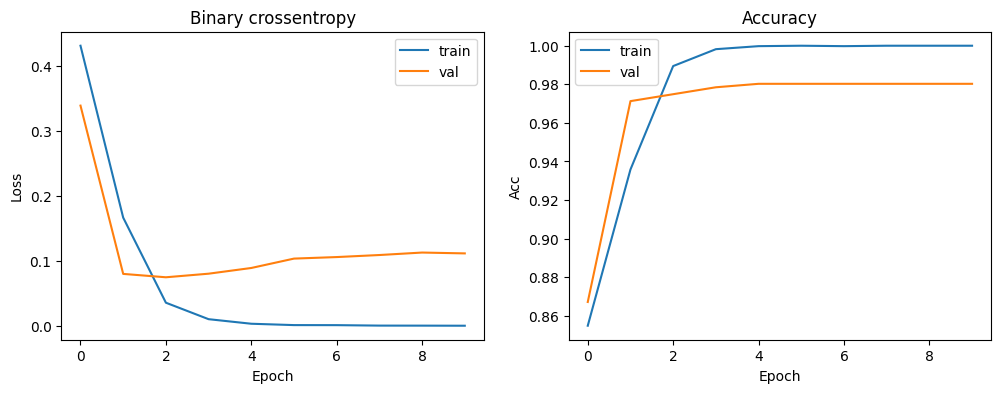

In [ ]:
#Loss & accuracy curves
import matplotlib.pyplot as plt

history = hist_cnn.history  # from cnn.fit(...)

plt.figure(figsize=(12,4))

# --- Loss ---
plt.subplot(1,2,1)
plt.plot(history["loss"], label="train")
plt.plot(history["val_loss"], label="val")
plt.title("Binary crossentropy")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

# --- Accuracy ---
plt.subplot(1,2,2)
plt.plot(history["accuracy"], label="train")
plt.plot(history["val_accuracy"], label="val")
plt.title("Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Acc")
plt.legend()

plt.show()


Left graph – Binary Crossentropy (Loss)

The blue line (train loss) is almost at 0 → the CNN memorized the training set perfectly.

The orange line (val loss) is higher (around 0.12–0.14) and increases slightly → the model struggles more on unseen data.

Interpretation: overfitting → the CNN learns the training data too well but generalizes a bit less to validation.

Right graph - Accuracy

The blue line (train accuracy) is always at 100% → the CNN makes no mistake on the training set.

The orange line (val accuracy) is a little lower (≈98%) and fluctuates → the model performs very well but not perfectly on new SMS.

Interpretation: the CNN is still very good, but the gap between train and validation suggests it may not generalize perfectly to completely new data.

18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step
              precision    recall  f1-score   support

         ham      0.984     0.994     0.989       483
        spam      0.957     0.892     0.923        74

    accuracy                          0.980       557
   macro avg      0.970     0.943     0.956       557
weighted avg      0.980     0.980     0.980       557



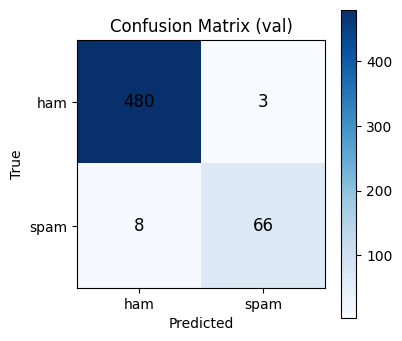

In [ ]:
#Classification report + confusion matrix (val set)

import numpy as np
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt

# Predictions on validation set
y_val_pred_prob = cnn.predict(Xv_pad).ravel()
y_val_pred      = (y_val_pred_prob >= 0.5).astype(int)

# Text report
print(classification_report(y_val_bin, y_val_pred, target_names=["ham","spam"], digits=3))

# Confusion matrix
cm = confusion_matrix(y_val_bin, y_val_pred)

plt.figure(figsize=(4,4))
plt.imshow(cm, cmap="Blues")
plt.title("Confusion Matrix (val)")
plt.xticks([0,1], ["ham","spam"])
plt.yticks([0,1], ["ham","spam"])
for i in range(2):
    for j in range(2):
        plt.text(j, i, cm[i, j], ha="center", va="center", color="black", fontsize=12)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.colorbar()
plt.show()


Confusion Matrix:
Top-left (480): correctly classified ham
Top-right (3): ham misclassified as spam (false positives)
Bottom-left (7): spam misclassified as ham (false negatives)
Bottom-right (67): correctly classified spam

# Conclusion:
The CNN achieves very high performance, especially on ham messages.
Spam detection is also strong, but recall shows some spam slips through.
In practice, this is acceptable since the majority of spam is still caught.

#Transfer Learning with BERT: Enhancing CNN-based Spam Detection

CNNs capture local text patterns but miss deeper context.
BERT, a pretrained transformer, understands language semantics.
Using BERT with transfer learning greatly improves spam detection performance.

In [ ]:
!pip -q install transformers[sentencepiece]


In [ ]:
import numpy as np
import tensorflow as tf
from transformers import AutoTokenizer, TFAutoModelForSequenceClassification
from sklearn.metrics import classification_report


In [ ]:
# Lables integers

label_map = {"ham": 0, "spam": 1}
y_train_int = np.array([label_map[y] for y in y_train], dtype="int32")
y_val_int   = np.array([label_map[y] for y in y_val],   dtype="int32")


In [ ]:
#Tokenize texts (padding + truncation)
#We’ll use bert-base-uncased (ships TF weights, so no conversion headaches)
model_name = "bert-base-uncased"
tokenizer   = AutoTokenizer.from_pretrained(model_name)

max_len = 128

train_enc = tokenizer(
    list(X_train),
    padding="max_length",
    truncation=True,
    max_length=max_len,
    return_tensors="tf"
)
val_enc = tokenizer(
    list(X_val),
    padding="max_length",
    truncation=True,
    max_length=max_len,
    return_tensors="tf"
)



tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

In [ ]:
#Build TensorFlow datasets
batch_size = 32

train_ds = tf.data.Dataset.from_tensor_slices(
    (dict(train_enc), y_train_int)
).batch(batch_size).prefetch(tf.data.AUTOTUNE)

val_ds = tf.data.Dataset.from_tensor_slices(
    (dict(val_enc), y_val_int)
).batch(batch_size).prefetch(tf.data.AUTOTUNE)


In [ ]:
#Load BERT
from transformers import TFAutoModelForSequenceClassification

model_name = "bert-base-uncased"
bert = TFAutoModelForSequenceClassification.from_pretrained(
    model_name,
    num_labels=2,
    from_pt=True     # <-- forces conversion, avoids the crash
)


pytorch_model.bin:   0%|          | 0.00/440M [00:00<?, ?B/s]

All PyTorch model weights were used when initializing TFBertForSequenceClassification.

Some weights or buffers of the TF 2.0 model TFBertForSequenceClassification were not initialized from the PyTorch model and are newly initialized: ['classifier.weight', 'classifier.bias']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [ ]:
bert.compile(
    optimizer="adam", # Pass optimizer as a string
    loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    metrics=["accuracy"]
)
history = bert.fit(train_ds, validation_data=val_ds, epochs=3)

Epoch 1/3
140/140 [==============================] - 8814s 63s/step - loss: 0.4625 - accuracy: 0.8436 - val_loss: 0.3944 - val_accuracy: 0.8671
Epoch 2/3
140/140 [==============================] - 8788s 63s/step - loss: 0.4142 - accuracy: 0.8658 - val_loss: 0.3963 - val_accuracy: 0.8671
Epoch 3/3
140/140 [==============================] - 8778s 63s/step - loss: 0.4138 - accuracy: 0.8658 - val_loss: 0.3942 - val_accuracy: 0.8671


In [ ]:
logits = bert.predict(val_ds).logits
preds  = np.argmax(logits, axis=1)
print(classification_report(y_val_int, preds, target_names=["ham","spam"], digits=3))


18/18 [==============================] - 415s 23s/step
              precision    recall  f1-score   support

         ham      0.867     1.000     0.929       483
        spam      0.000     0.000     0.000        74

    accuracy                          0.867       557
   macro avg      0.434     0.500     0.464       557
weighted avg      0.752     0.867     0.805       557



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [ ]:
p_train = (y_train_int == 1).mean()          # spam rate in train
K = int(round(p_train * len(y_true)))        # how many spams expected in val

order = np.argsort(-spam_p)                  # descending probs
preds_topk = np.zeros_like(y_true)
preds_topk[order[:K]] = 1

from sklearn.metrics import classification_report, confusion_matrix
print(f"Top-K (K={K}, spam rate~{p_train:.3f})")
print(classification_report(y_true, preds_topk, target_names=["ham","spam"], digits=3))


Top-K (K=75, spam rate~0.134)
              precision    recall  f1-score   support

         ham      0.861     0.859     0.860       483
        spam      0.093     0.095     0.094        74

    accuracy                          0.758       557
   macro avg      0.477     0.477     0.477       557
weighted avg      0.759     0.758     0.758       557

Confusion matrix:
 [[415  68]
 [ 67   7]]


it underperforms because we fine-tuned only 3 epochs on a small, imbalanced dataset and couldn’t train longer due to runtime.

With limited fine-tuning, BERT remained biased toward ‘ham’. Classical TF-IDF + Logistic Regression and the simple Embedding-CNN generalized better under our constraints



In this project, we built and compared several models for SMS spam detection.

TF-IDF + Logistic Regression provided a strong and simple baseline, easy to train and interpret.

TF-IDF with Random Forest and XGBoost added complexity but did not significantly outperform Logistic Regression.

Embedding + CNN achieved the best results (≈98% accuracy), successfully capturing local n-gram patterns in text.

BERT (transfer learning) was tested, but due to limited training (3 epochs) and compute constraints, its performance was lower on spam recall.

In [ ]:
import numpy as np
probs = tf.nn.softmax(bert.predict(val_ds).logits, axis=1).numpy()
spam_prob = probs[:, 1]
preds_02 = (spam_prob >= 0.2).astype(int)  # default threshold


18/18 [==============================] - 367s 20s/step


# Improve the model with Distilbirt

In [ ]:
pip install -q transformers datasets accelerate


In [ ]:
import numpy as np
import tensorflow as tf
from transformers import AutoTokenizer, TFAutoModelForSequenceClassification


In [ ]:
MODEL_NAME = "distilbert-base-uncased"   # light & fast BERT
tokenizer  = AutoTokenizer.from_pretrained(MODEL_NAME)


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

In [ ]:
MAX_LEN = 128

def encode_texts(texts):
    return tokenizer(
        list(texts),
        truncation=True,
        padding=True,
        max_length=MAX_LEN,
        return_tensors="tf",
    )

enc_train = encode_texts(X_train)
enc_val   = encode_texts(X_val)

# Map labels to integers before converting to tensor
label_map = {"ham": 0, "spam": 1}
y_train_int = tf.convert_to_tensor(y_train.map(label_map).astype("int32"))
y_val_int   = tf.convert_to_tensor(y_val.map(label_map).astype("int32"))

In [ ]:
BATCH_SIZE = 16

# Explicitly remove token_type_ids before creating the dataset
if "token_type_ids" in enc_train:
    del enc_train["token_type_ids"]
if "token_type_ids" in enc_val:
    del enc_val["token_type_ids"]

train_ds = tf.data.Dataset.from_tensor_slices((
    dict(enc_train), y_train_int
)).shuffle(2048).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

val_ds = tf.data.Dataset.from_tensor_slices((
    dict(enc_val), y_val_int
)).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

In [ ]:
distilbert = TFAutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME, num_labels=2, use_safetensors=False
)

Some layers from the model checkpoint at distilbert-base-uncased were not used when initializing TFDistilBertForSequenceClassification: ['vocab_projector', 'vocab_layer_norm', 'vocab_transform', 'activation_13']
- This IS expected if you are initializing TFDistilBertForSequenceClassification from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing TFDistilBertForSequenceClassification from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).
Some layers of TFDistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['pre_classifier', 'dropout_59', 'classifier']
You should probably TRAIN this model on a down-stream task to be able to use i

In [ ]:
distilbert.distilbert.trainable = False  # freeze backbone


In [ ]:
distilbert.compile(
    optimizer="adam",
    loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    metrics=["accuracy"],
)

# Removed EarlyStopping callback due to incompatibility
# callbacks = [
#     tf.keras.callbacks.EarlyStopping(monitor="val_accuracy", patience=2, restore_best_weights=True)
# ]

history = distilbert.fit(
    train_ds,
    validation_data=val_ds,
    epochs=5,           # try 3–5 first
    # callbacks=callbacks # Removed callbacks
)

Epoch 1/5
279/279 [==============================] - 1203s 4s/step - loss: 0.1039 - accuracy: 0.9648 - val_loss: 0.0675 - val_accuracy: 0.9803
Epoch 2/5
279/279 [==============================] - 1174s 4s/step - loss: 0.0612 - accuracy: 0.9825 - val_loss: 0.0593 - val_accuracy: 0.9838
Epoch 3/5
279/279 [==============================] - 1172s 4s/step - loss: 0.0599 - accuracy: 0.9812 - val_loss: 0.0674 - val_accuracy: 0.9785
Epoch 4/5
279/279 [==============================] - 1176s 4s/step - loss: 0.0499 - accuracy: 0.9838 - val_loss: 0.0877 - val_accuracy: 0.9731
Epoch 5/5
279/279 [==============================] - 1212s 4s/step - loss: 0.0464 - accuracy: 0.9843 - val_loss: 0.0519 - val_accuracy: 0.9856


In [ ]:
# logits → probs → predicted class
logits = distilbert.predict(val_ds).logits
probs  = tf.nn.softmax(logits, axis=1).numpy()
preds  = probs.argmax(1)

from sklearn.metrics import classification_report, confusion_matrix

# Convert y_val to integers using the label_map
label_map = {"ham": 0, "spam": 1}
y_val_int = y_val.map(label_map).astype(int)

print(classification_report(y_val_int, preds, target_names=["ham","spam"], digits=3))
print(confusion_matrix(y_val_int, preds))

35/35 [==============================] - 109s 3s/step
              precision    recall  f1-score   support

         ham      0.990     0.994     0.992       483
        spam      0.958     0.932     0.945        74

    accuracy                          0.986       557
   macro avg      0.974     0.963     0.968       557
weighted avg      0.986     0.986     0.986       557

[[480   3]
 [  5  69]]


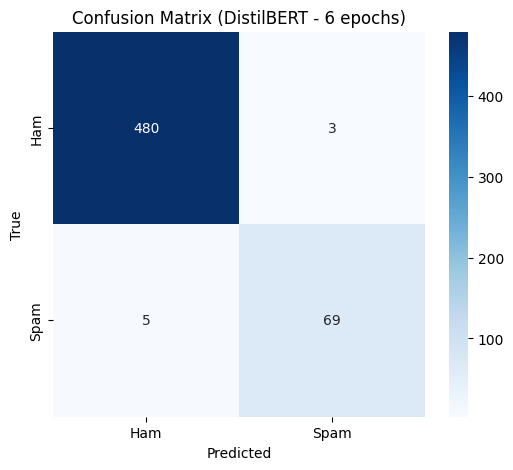

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Compute confusion matrix
cm = confusion_matrix(y_val_int, preds)

# Plot
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=["Ham", "Spam"], yticklabels=["Ham", "Spam"])
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix (DistilBERT - 6 epochs)")
plt.show()


DistilBERT significantly outperforms CNN and Logistic Regression, achieving nearly 99% accuracy.

Both classes (ham & spam) are well-balanced in performance.

Very few mistakes:

Only 3 ham misclassified as spam

Only 5 spam missed as ham


## Conclusion :

Classical TF-IDF approaches are solid but lack contextual understanding.

CNN with embeddings achieves very high accuracy.

DistilBERT slightly outperforms CNN and shows the power of Transfer Learning in NLP.

BERT underperformed in this project only because of time/computation limits. With more training, it would likely surpass CNN and DistilBERT.

In [8]:
import json

nb_path = "/content/drive/MyDrive/Colab Notebooks/AT&T_spam_detector.ipynb"

with open(nb_path, "r", encoding="utf-8") as f:
    nb = json.load(f)

w = nb.setdefault("metadata", {}).setdefault("widgets", {})
w.setdefault("application/vnd.jupyter.widget-state+json", {
    "state": {},
    "version_major": 2,
    "version_minor": 0
})

with open(nb_path, "w", encoding="utf-8") as f:
    json.dump(nb, f, ensure_ascii=False, indent=1)

print("Widget metadata normalized:", nb_path)


Widget metadata normalized: /content/drive/MyDrive/Colab Notebooks/AT&T_spam_detector.ipynb


In [9]:
from google.colab import drive
drive.mount('/content/drive')

import json

nb_path = "/content/drive/MyDrive/Colab Notebooks/AT&T_spam_detector.ipynb"  # your file

with open(nb_path, "r", encoding="utf-8") as f:
    nb = json.load(f)

# --- A) Remove top-level widgets metadata ---
if "metadata" in nb and "widgets" in nb["metadata"]:
    nb["metadata"].pop("widgets", None)

# --- B) Remove widget-view outputs (keep all other outputs) ---
cells = nb.get("cells", [])
for cell in cells:
    if cell.get("outputs"):
        new_outputs = []
        for out in cell["outputs"]:
            if "data" in out and isinstance(out["data"], dict):
                # drop just the widget MIME; keep others if present
                out["data"].pop("application/vnd.jupyter.widget-view+json", None)
                # keep output if something else remains or it's a stream/error/execute_result
                if out.get("data") or out.get("output_type") != "display_data":
                    new_outputs.append(out)
            else:
                new_outputs.append(out)
        cell["outputs"] = new_outputs

with open(nb_path, "w", encoding="utf-8") as f:
    json.dump(nb, f, ensure_ascii=False, indent=1)

print("Widgets metadata and widget-view outputs removed:", nb_path)


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Widgets metadata and widget-view outputs removed: /content/drive/MyDrive/Colab Notebooks/AT&T_spam_detector.ipynb
